#### Aufgabe: Random Forest

Shape: (569, 30)
Missing values: 0

=== RandomForest ===
Accuracy: 0.935672514619883
Classification Report:
               precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171


=== XGBoost ===
Accuracy: 0.9649122807017544
Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.92      0.95        64
      benign       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.97      0.96      0.96       171


=== LightGBM ===
Accuracy: 0.9649122807017544
Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.92      0.

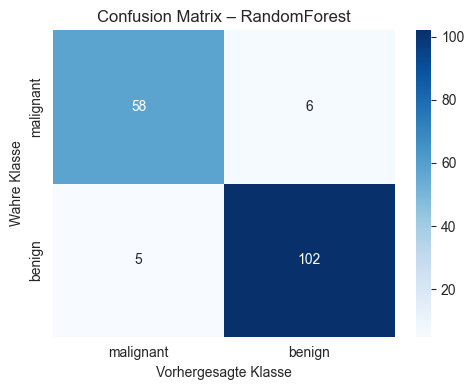

In [5]:
# ===========================================
# Imports
# ===========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ===========================================
# 1. Daten laden
# ===========================================
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape:", X.shape)
print("Missing values:", X.isna().sum().sum())

# ===========================================
# 2. Train/Test-Split (mit DataFrames)
# ===========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ===========================================
# 3. StandardScaler, aber DataFrame bleibt erhalten
# ===========================================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# ===========================================
# 4. Modelle definieren
# ===========================================
models = {
    "RandomForest": RandomForestClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )
}

results = {}

# ===========================================
# 5. Modelle trainieren & bewerten (mit DataFrame Input)
# ===========================================
for name, model in models.items():
    model.fit(X_train_scaled, y_train)      # Train mit DF + Feature-Namen
    y_pred = model.predict(X_test_scaled)   # Predict mit DF + Feature-Namen

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("Classification Report:\n",
          classification_report(y_test, y_pred, target_names=data.target_names))

# ===========================================
# 6. Modellvergleich
# ===========================================
print("\n=== Modellvergleich (Accuracy) ===")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# ===========================================
# 7. Confusion Matrix für RandomForest
# ===========================================
rf = models["RandomForest"]
y_pred_rf = rf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Wahre Klasse")
plt.title("Confusion Matrix – RandomForest")
plt.tight_layout()
plt.show()


#### Aufgabe: Random Forest mit Feature Engineering

Erste Zeilen:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \

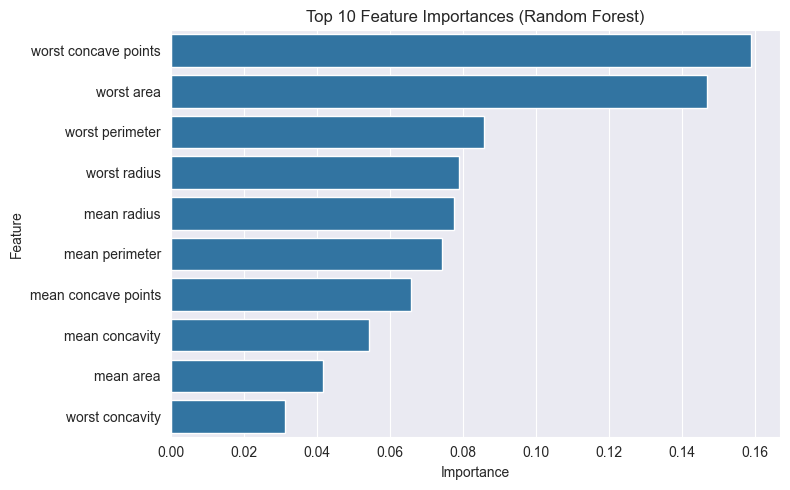

=== Random Forest (Top 10 Features) ===
              precision    recall  f1-score   support

   malignant       0.95      0.89      0.92        64
      benign       0.94      0.97      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171

Confusion Matrix:
 [[ 57   7]
 [  3 104]]
RF (Top 10) Accuracy: 0.9415

Training XGBoost Classifier with Default Parameters...
=== XGBoost (Default, Top 10) ===
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        64
      benign       0.95      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171

Confusion Matrix:
 [[ 58   6]
 [  2 105]]
XGBoost Accuracy: 0.9532

Starting Hyperparameter Tuning for XGBoost...
Best Parameters Found: {'learni

In [3]:
# -------------------------------
# 1. Import der Pakete
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API.*")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# -------------------------------
# 2. Daten laden und vorbereiten
# -------------------------------
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Erste Zeilen:\n", df.head(), "\n")
print("Missing Values gesamt:", df.isna().sum().sum(), "\n")

X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=data.feature_names, index=df.index)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------------
# 3. Random Forest (alle Features)
# -------------------------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest (Alle Features) ===")
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}\n")

# -------------------------------
# 4. Feature Importance + Top 10
# -------------------------------
importances = rf.feature_importances_
feature_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

top_features = feature_importances.index[:10].tolist()
print(f"Top 10 Features Selected: {top_features}\n")

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.iloc[:10].values, y=feature_importances.iloc[:10].index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

X_fe = X[top_features]
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.3, random_state=42, stratify=y
)

rf_fe = RandomForestClassifier(random_state=42)
rf_fe.fit(X_train_fe, y_train_fe)
y_pred_rf_fe = rf_fe.predict(X_test_fe)

print("=== Random Forest (Top 10 Features) ===")
print(classification_report(y_test_fe, y_pred_rf_fe, target_names=data.target_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, y_pred_rf_fe))
rf_fe_accuracy = accuracy_score(y_test_fe, y_pred_rf_fe)
print(f"RF (Top 10) Accuracy: {rf_fe_accuracy:.4f}\n")

# -------------------------------
# 5. XGBoost Default (Top 10)
# -------------------------------
print("Training XGBoost Classifier with Default Parameters...")
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_fe, y_train_fe)
y_pred_xgb = xgb.predict(X_test_fe)

print("=== XGBoost (Default, Top 10) ===")
print(classification_report(y_test_fe, y_pred_xgb, target_names=data.target_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, y_pred_xgb))
print(f"XGBoost Accuracy: {accuracy_score(y_test_fe, y_pred_xgb):.4f}\n")

# -------------------------------
# 6. XGB Hyperparameter Tuning (ohne Multiprocessing-Warnung)
# -------------------------------
print("Starting Hyperparameter Tuning for XGBoost...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=0,
    n_jobs=1  # <-- wichtig: vermeidet multiprocessing/pkg_resources-Warnung
)

grid_search.fit(X_train_fe, y_train_fe)

best_params = grid_search.best_params_
print(f"Best Parameters Found: {best_params}\n")

best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train_fe, y_train_fe)
y_pred_best_xgb = best_xgb.predict(X_test_fe)

print("=== XGBoost (Tuned, Top 10) ===")
print(classification_report(y_test_fe, y_pred_best_xgb, target_names=data.target_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, y_pred_best_xgb))
print(f"Tuned XGBoost Accuracy: {accuracy_score(y_test_fe, y_pred_best_xgb):.4f}\n")

# -------------------------------
# 7. LightGBM Default (Top 10)
# -------------------------------
print("Training LightGBM Classifier with Default Parameters...")
lgbm = LGBMClassifier(random_state=42, verbose=-1)
lgbm.fit(X_train_fe, y_train_fe)
y_pred_lgbm = lgbm.predict(X_test_fe)

print("=== LightGBM (Default, Top 10) ===")
print(classification_report(y_test_fe, y_pred_lgbm, target_names=data.target_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, y_pred_lgbm))
print(f"LightGBM Accuracy: {accuracy_score(y_test_fe, y_pred_lgbm):.4f}\n")
